## 목표
- EDA 및 시각화
- 다중 분류 모델 실습 (scikit - learn)
- 분류 성능 평가 및 지표에 대한 이해

### 컬럼 설명

- gender: 학생의 성별 (M: 남성, F: 여성)
- NationaliTy: 학생의 국적
- PlaceofBirth: 학생이 태어난 국가
- StageID: 학생이 다니는 학교 (초,중,고)
- GradeID: 학생이 속한 성적 등급
- SectionID: 학생이 속한 반 이름
- Topic: 수강한 과목
- Semester: 수강한 학기 (1학기/2학기)
- Relation: 주 보호자와 학생의 관계
- raisedhands: 학생이 수업 중 손을 든 횟수
- VisITedResources: 학생이 과목 공지를 확인한 횟수
- Discussion: 학생이 토론 그룹에 참여한 횟수
- ParentAnsweringSurvey: 부모가 학교 설문에 참여했는지 여부
- ParentschoolSatisfaction: 부모가 학교에 만족했는지 여부
- StudentAbscenceDays: 학생의 결석 횟수 (7회 이상/미만)
- Class: 학생의 성적 등급 (L: 낮음, M: 보통, H: 높음)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#한글 폰트 적용
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

In [3]:
df = pd.read_csv('./xAPI-Edu-Data.csv', encoding='cp949')

In [4]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


## 피처 선택을 위한 EDA

In [5]:
#데이터 타입 및 컬럼들 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [6]:
#결측치 확인
df.isnull().sum()

gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

### 변수 나누기

In [7]:
# 데이터 타입에 따라 컬럼 분류
categorical = df.select_dtypes(include=['object']).columns.tolist()
numeric = df.select_dtypes(include=['int64', 'float64']).columns.tolist()


#### 범주형 변수 : gender, NationalITy, PlaceofBirth, StageID, GradeID, SectionID, Topic, Semester, Relation, ParentAnsweringSurvey, ParentschoolSatisfaction, StudentAbsenceDays, Class
#### 수치형 변수 : raisedhands, VisITedResources, AnnouncementsView, Discussion

In [8]:
def make_plots(data_frame, categorical, n_cols=3):
    # 행 수 계산
    n_rows = (len(categorical) + n_cols - 1) // n_cols
    
    # 전체 그림 크기 설정
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 5))
    
    # 축 평탄화 (1차원 배열로 변환)
    if n_rows > 1 or n_cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    # 각 범주형 변수에 대한 그래프 그리기
    for i, column in enumerate(categorical):
        if i < len(axes):
            order = data_frame[column].value_counts().index.tolist()
            ax = sns.countplot(data=data_frame, x=column, order=order, ax=axes[i], hue=column)
            
            # 막대 위에 값 표시
            for container in ax.containers:
                ax.bar_label(container, fontsize=9)
            
            # x축 레이블 회전 (카테고리가 많을 경우)
            if len(order) > 5:
                ticks_loc = ax.get_xticks()
                ax.set_xticks(ticks_loc)
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            
            ax.set_title(f'{column} 분포', fontsize=12)
            ax.set_xlabel('')  # x축 레이블 제거
    
    # 사용하지 않는 서브플롯 제거
    for i in range(len(categorical), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()


### 범주형 변수 시각화

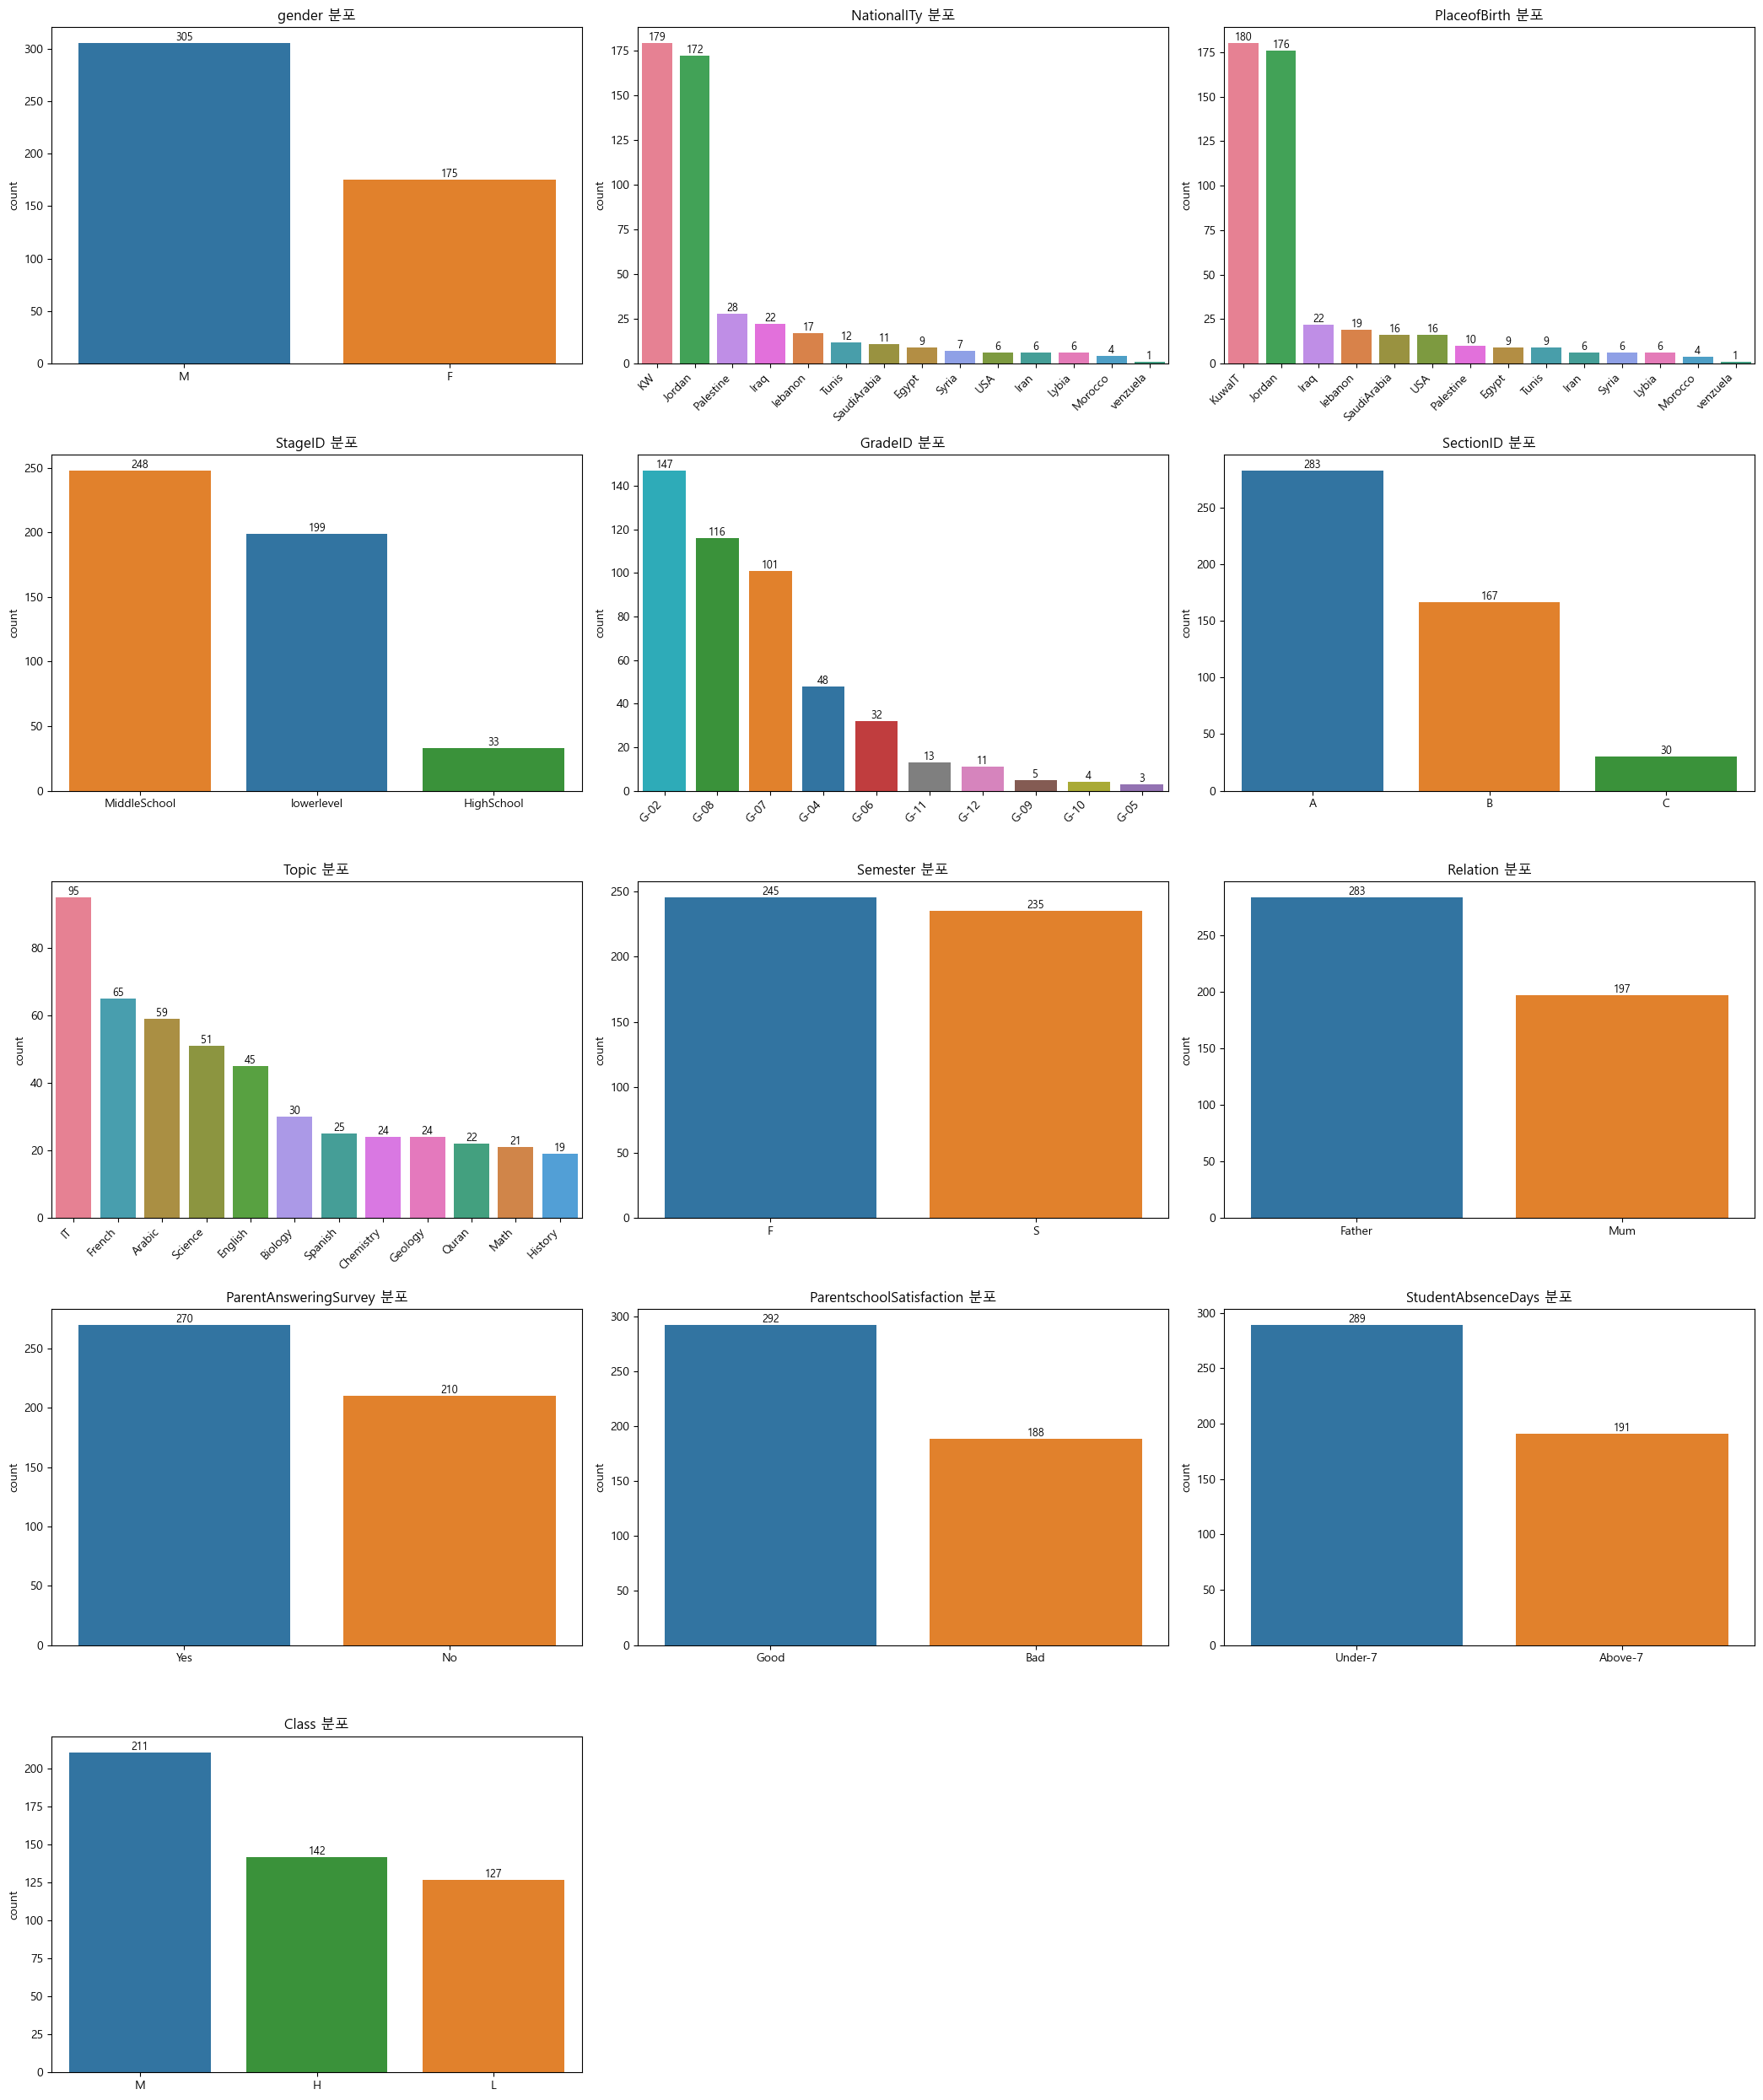

In [9]:
#범주형 변수 countplot 그리기
make_plots(df, categorical, n_cols=3)

### 수치형 변수 시각화

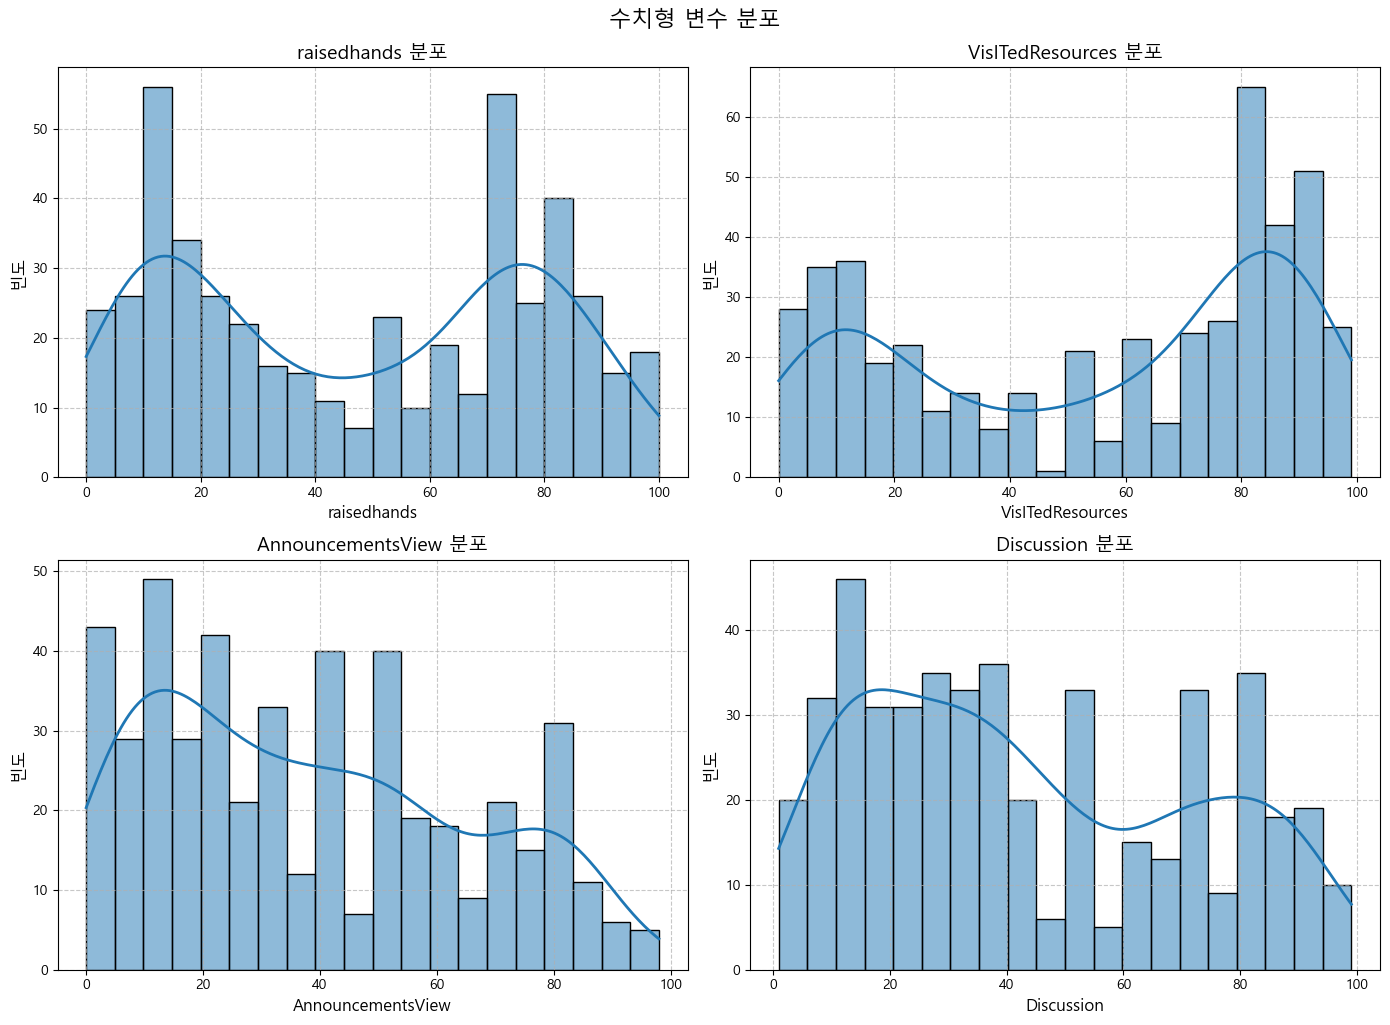

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 수치형 변수 목록
numeric_columns = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    # histplot으로 히스토그램 그리기 (kde 곡선 추가)
    sns.histplot(df[column], bins=20, kde=True, ax=axes[i], edgecolor='black', line_kws={'linewidth': 2})
    
    # 그래프 제목 및 레이블 설정
    axes[i].set_title(f'{column} 분포', fontsize=14)
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel('빈도', fontsize=12)
    
    # 그리드 추가
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('수치형 변수 분포', fontsize=16, y=1.02)
plt.show()


### 성적에서의 남여 분포

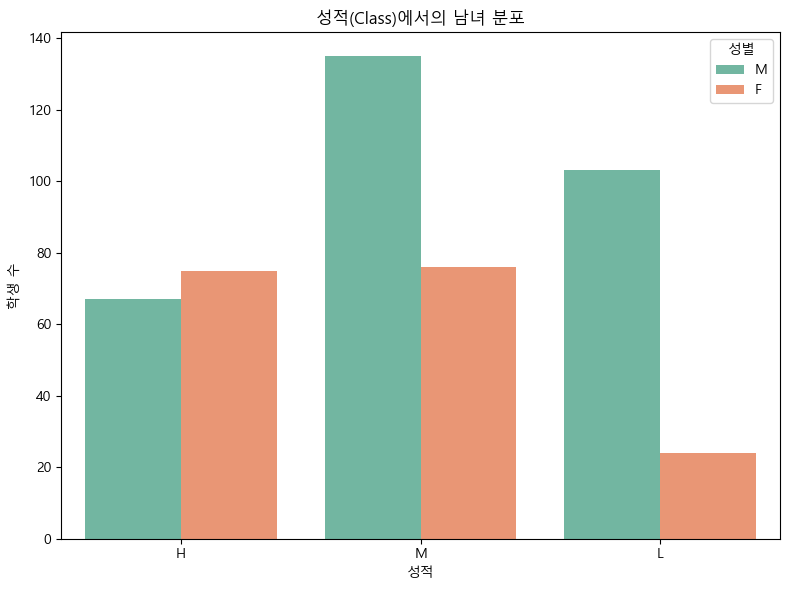

In [11]:
# 성적(Class)에서의 남녀 분포 시각화
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Class', hue='gender', palette='Set2', order=['H', 'M', 'L'])
plt.title('성적(Class)에서의 남녀 분포')
plt.xlabel('성적')
plt.ylabel('학생 수')
plt.legend(title='성별')
plt.tight_layout()
plt.show()

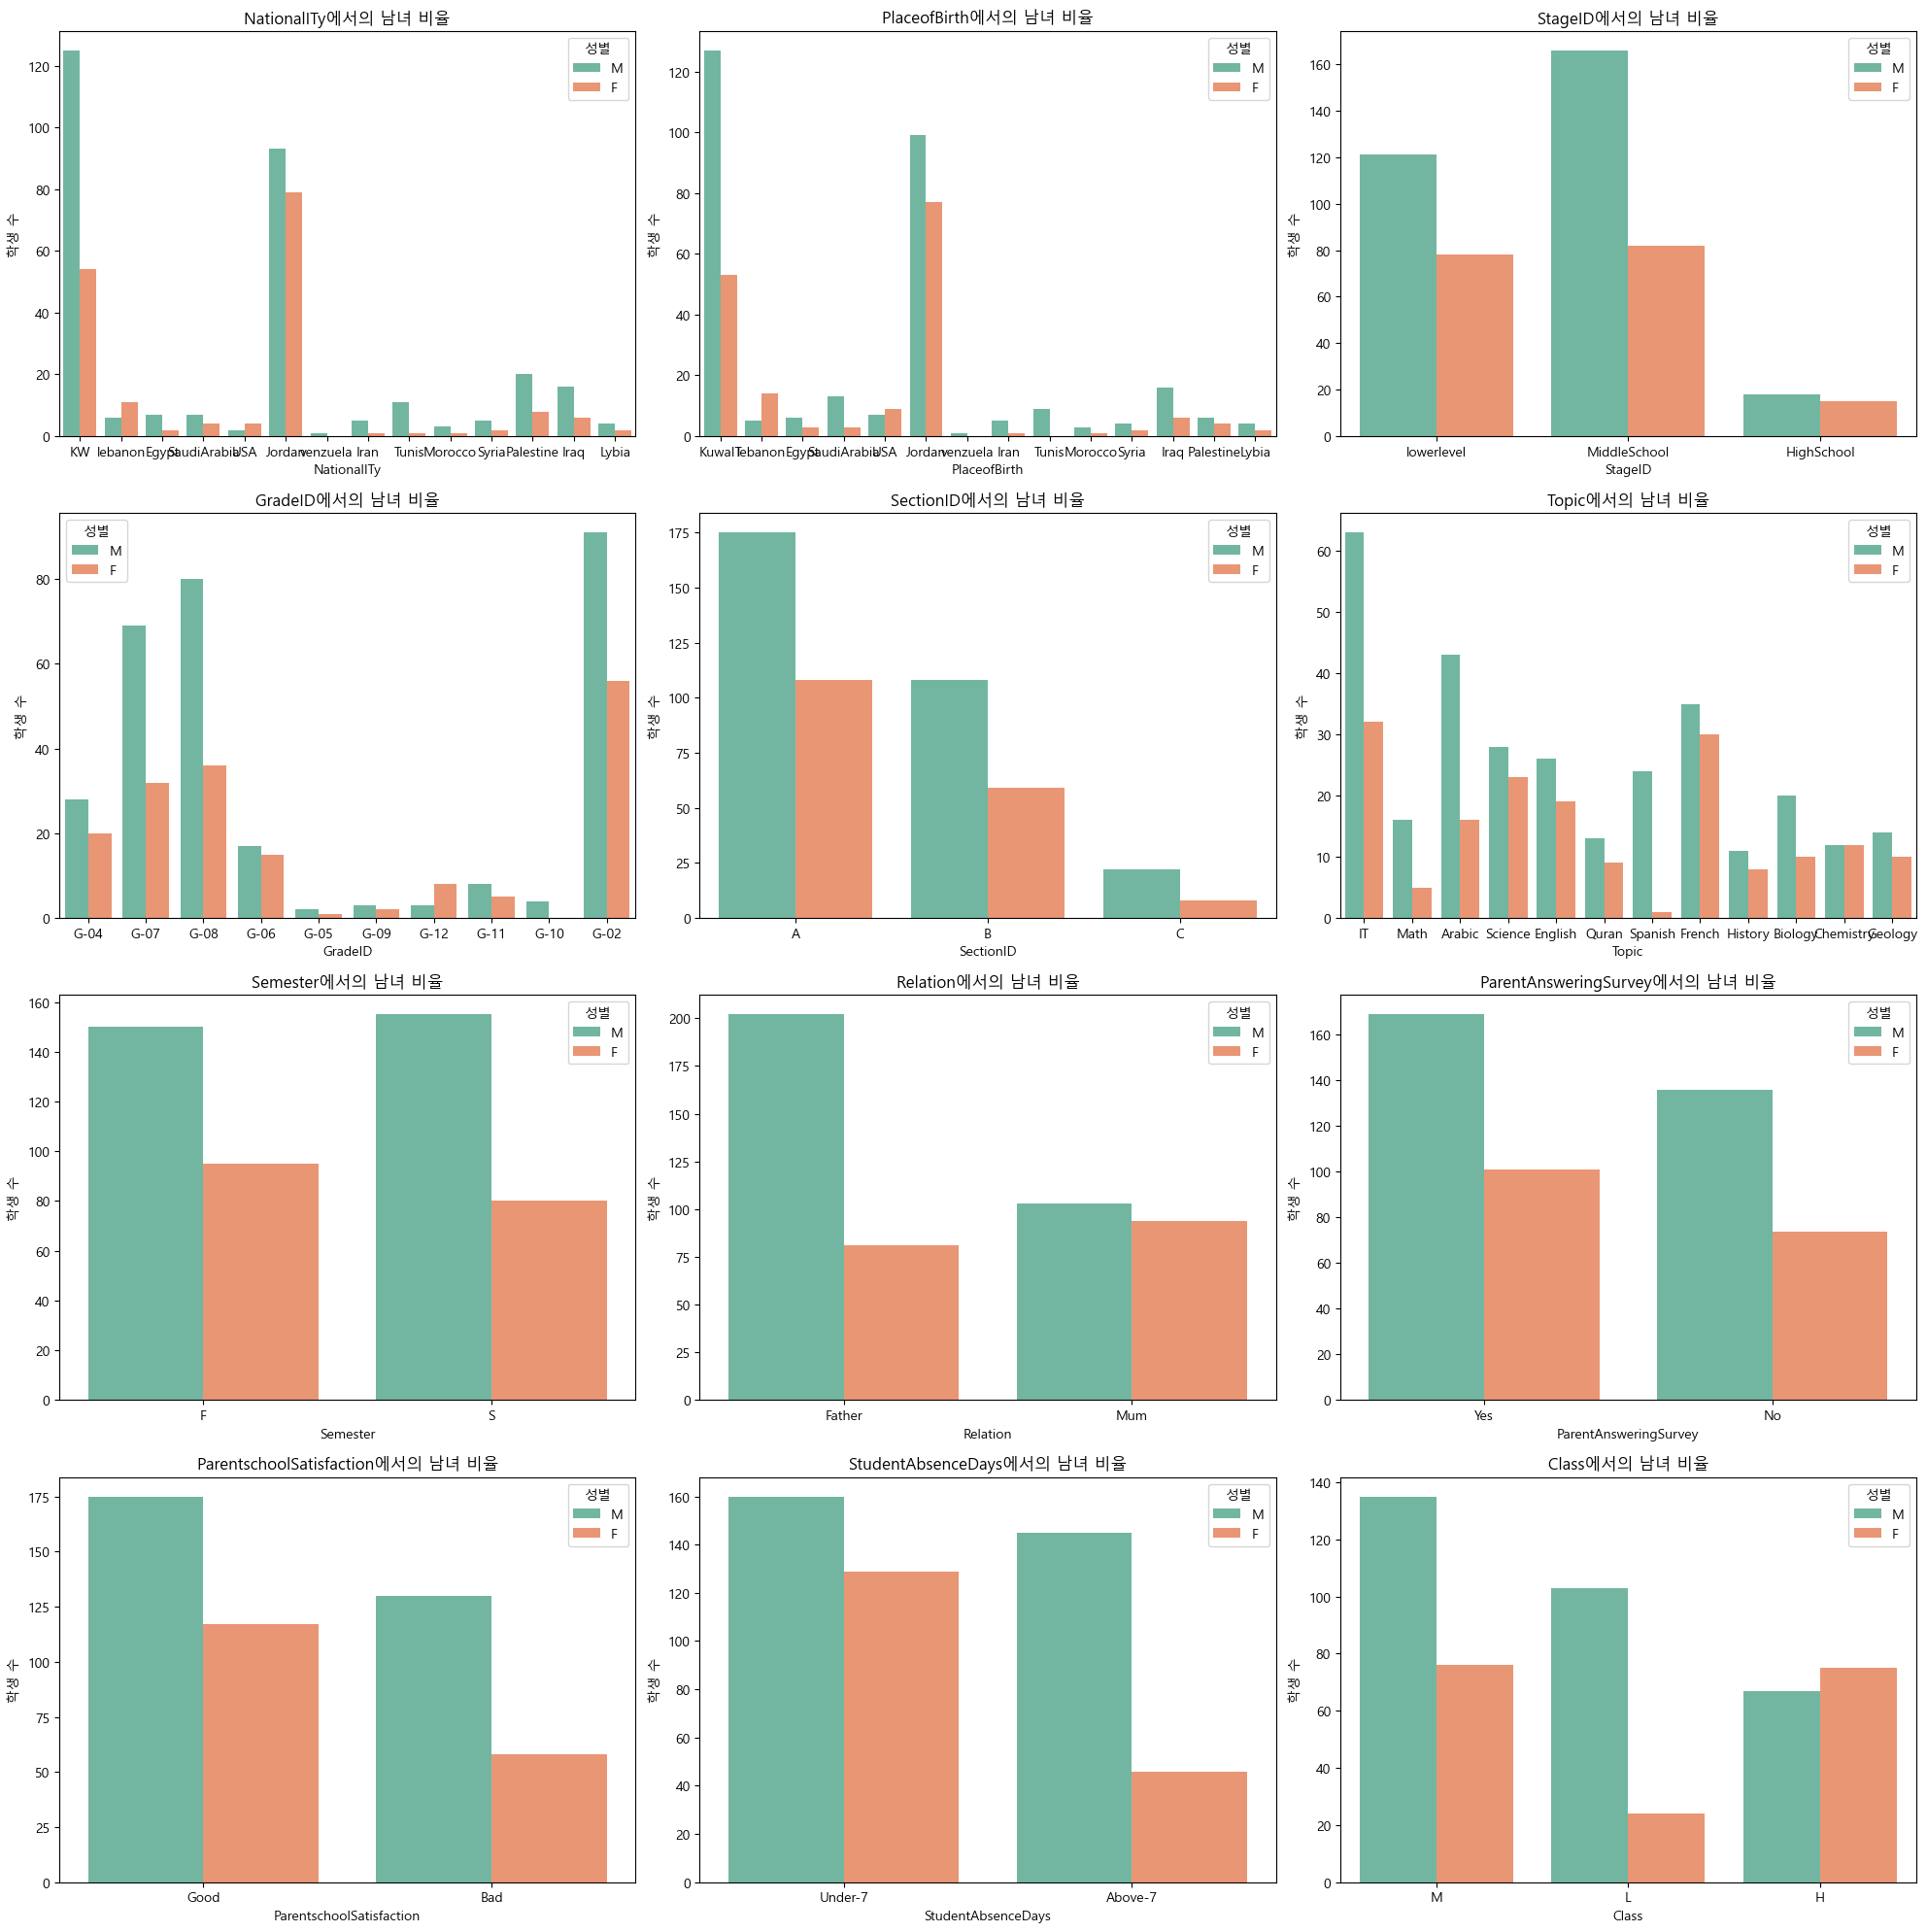

In [12]:
# 각 범주형 피처별 서브플롯 생성
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 20))
axes = axes.flatten()

count = 0  # 실제로 사용된 서브플롯 수를 추적하기 위한 카운터
for i, feature in enumerate(categorical):
    if feature == 'gender':
        continue  # gender는 건너뛰기
    else:
        sns.countplot(data=df, x=feature, hue='gender', palette='Set2', ax=axes[count])
        axes[count].set_title(f'{feature}에서의 남녀 비율')
        axes[count].set_xlabel(feature)
        axes[count].set_ylabel('학생 수')
        axes[count].legend(title='성별')
        axes[count].tick_params(axis='x')
        count += 1

# 사용하지 않는 서브플롯 제거
for j in range(count, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


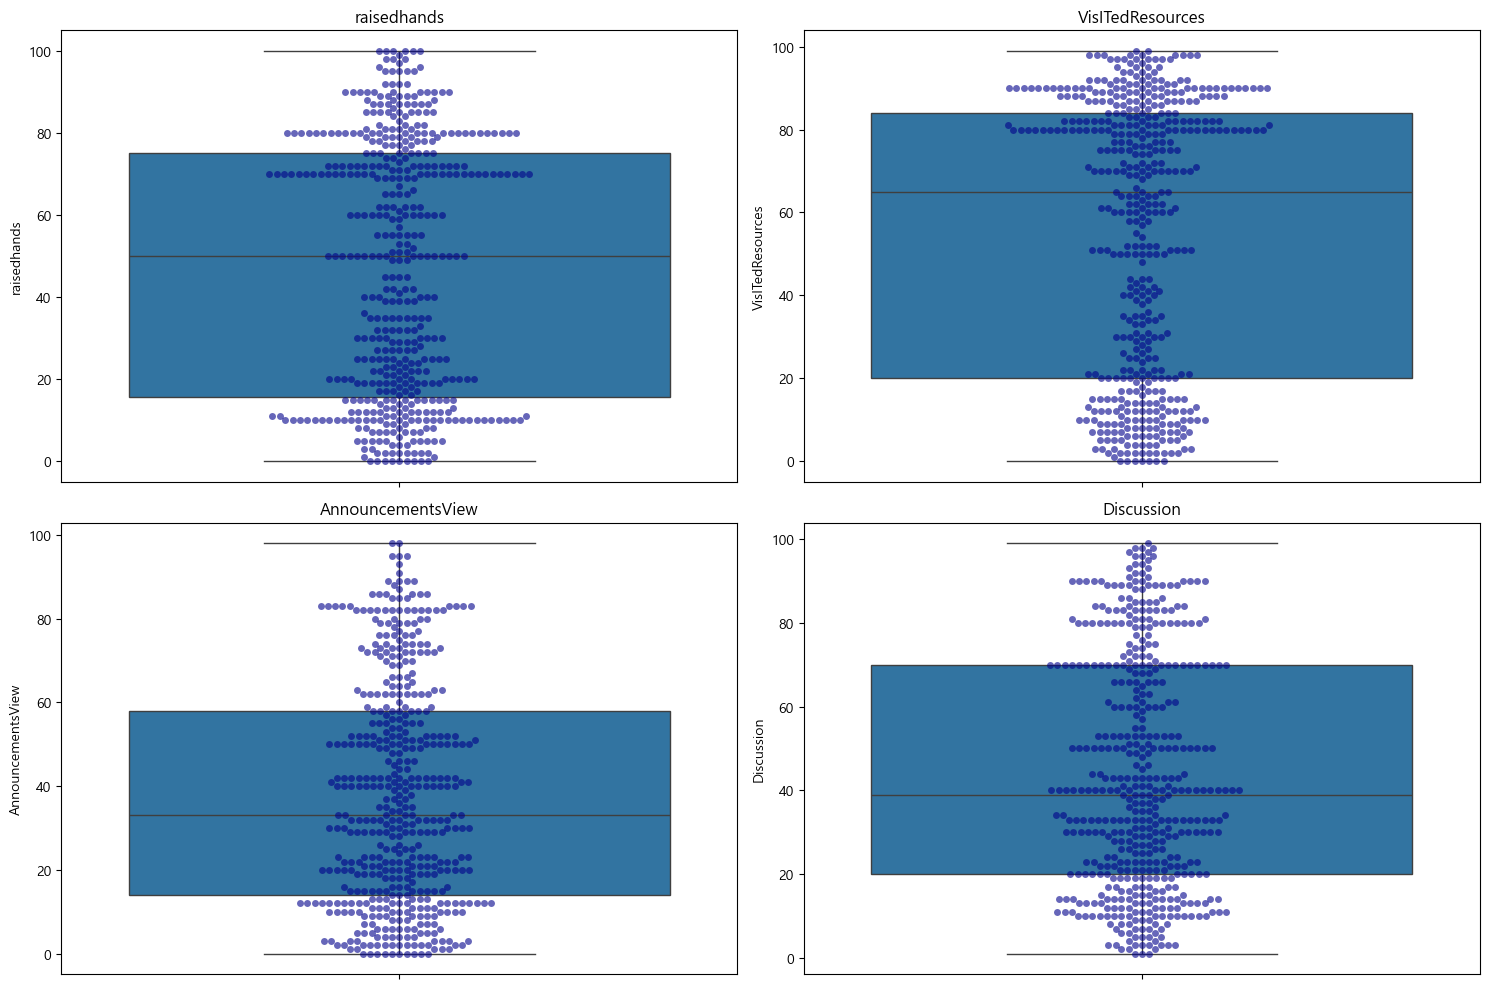

In [13]:
# 세로 boxplot과 swarmplot 함께 표시하기
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])  # 세로 방향 boxplot
    sns.swarmplot(y=df[col], color='darkblue', alpha=0.6)  # 데이터 포인트 분포 표시
    plt.title(col)
plt.tight_layout()
plt.show()

In [14]:
#Class를 타겟으로 하기위해서 categorical에 Class가있다면 제거

if 'Class' in categorical:
    categorical.remove('Class')

# H 클래스 이진 타겟 생성 (H vs non-H)
df['Class_H'] = (df['Class'] == 'H').astype(int)

# 원본 Class 컬럼 제외하고 특성과 타겟 분리
X = df.drop(['Class', 'Class_H'], axis=1)
y = df['Class_H']

# 범주형 변수 원-핫 인코딩
X_encoded = pd.get_dummies(X, columns=categorical, drop_first=True)

# 인코딩된 특성과 타겟 결합
df_combined = pd.concat([X_encoded, y], axis=1)

# 상관관계 행렬 계산
correlation_matrix = df_combined.corr()


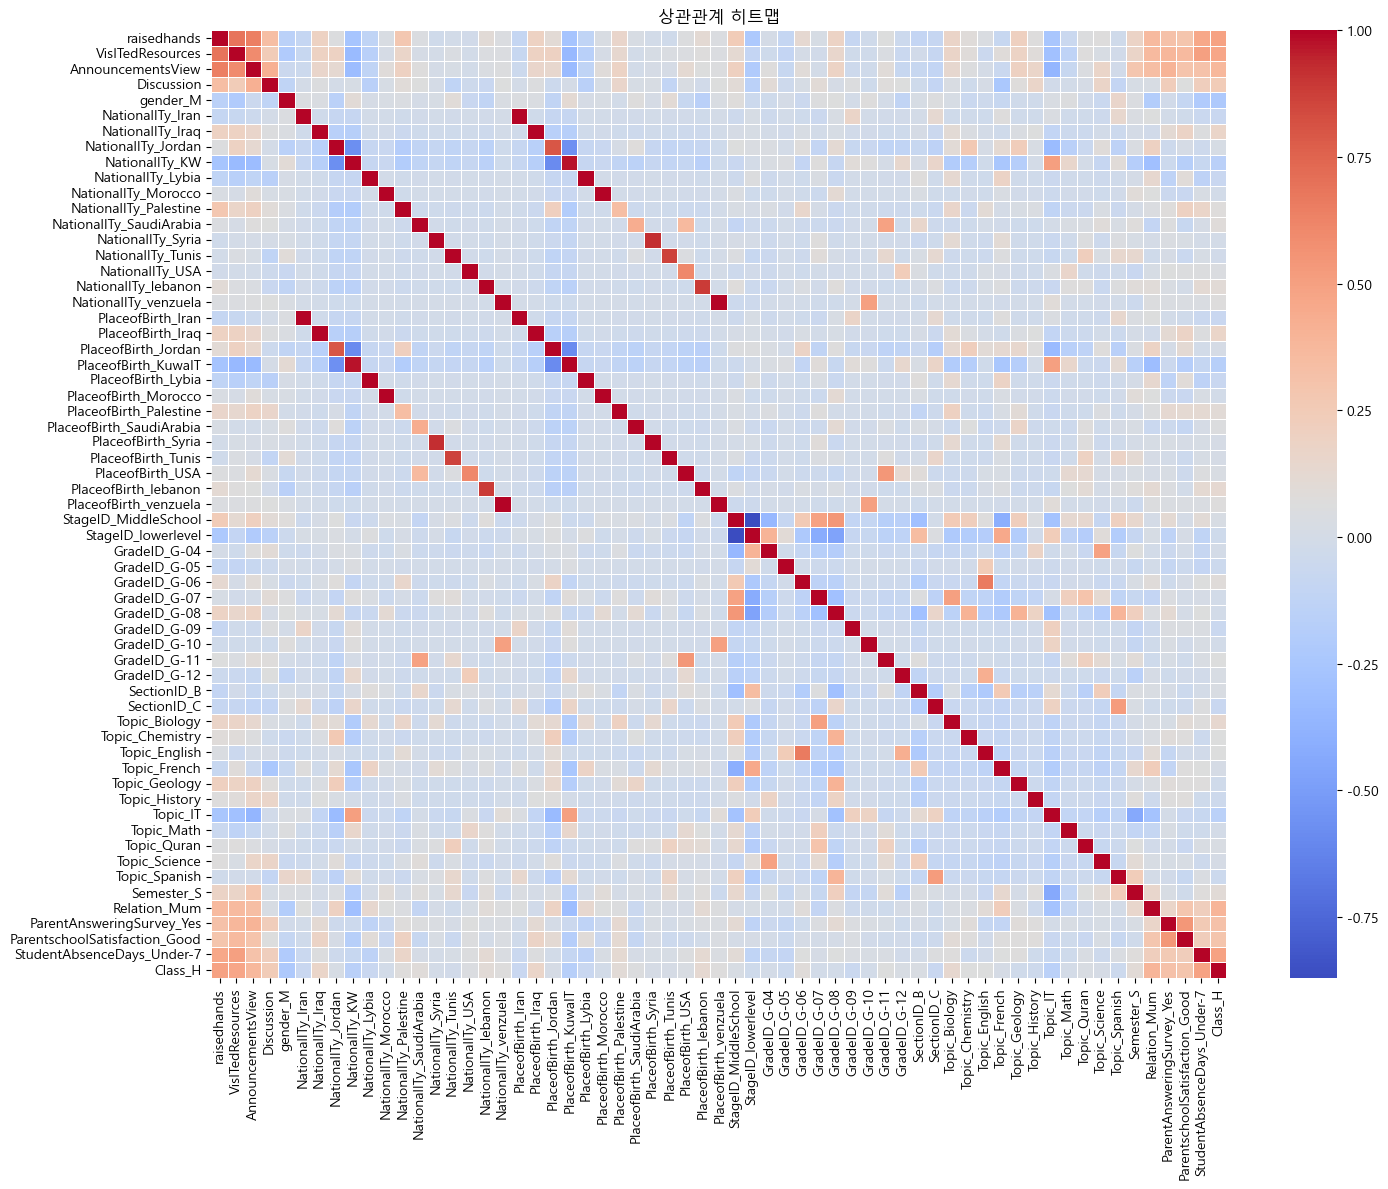

In [15]:
#상관관계 히트맵
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('상관관계 히트맵')
plt.tight_layout()
plt.show()

In [16]:
# H 클래스와 상관관계가 0.2 이상인 특성 선택
target_column = 'Class_H'
target_correlations = np.abs(correlation_matrix[target_column].sort_values(ascending=False))
selected_features = target_correlations[target_correlations >= 0.2]
selected_features_cols= target_correlations[target_correlations >= 0.2].index.tolist()

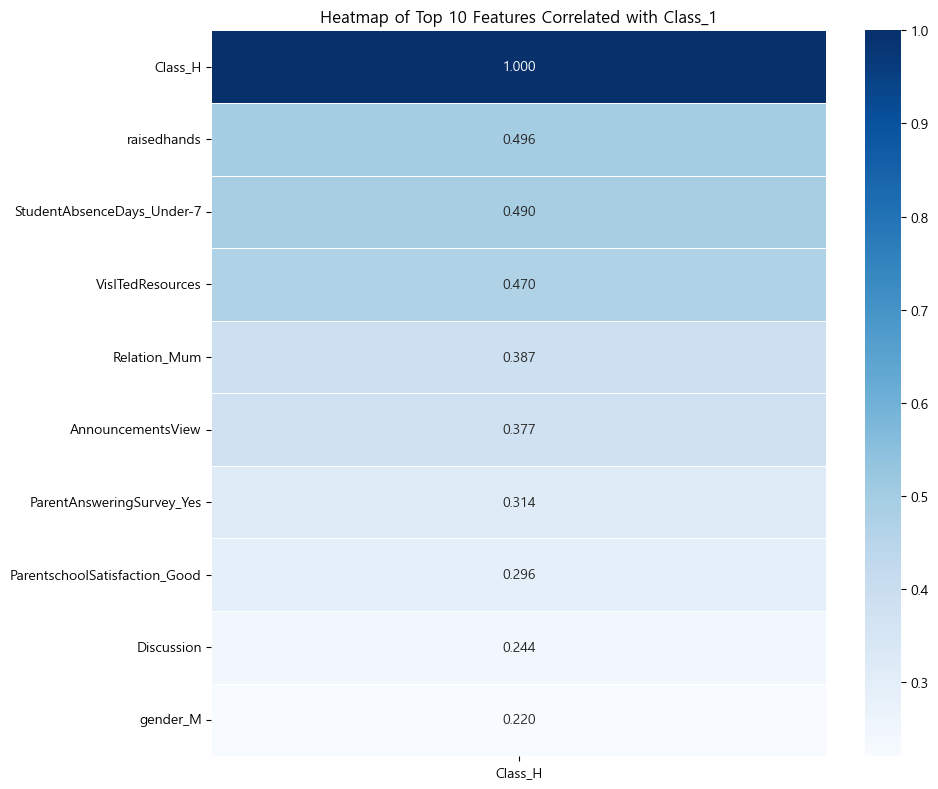

In [17]:
# 히트맵 생성
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(selected_features), annot=True, cmap='Blues', linewidths=0.5, fmt='.3f')
plt.title('Heatmap of Top 10 Features Correlated with Class_1')
plt.tight_layout()
plt.show()

In [18]:
X_vif = df_combined[selected_features_cols]
X_vif.dtypes

Class_H                          int32
raisedhands                      int64
StudentAbsenceDays_Under-7        bool
VisITedResources                 int64
Relation_Mum                      bool
AnnouncementsView                int64
ParentAnsweringSurvey_Yes         bool
ParentschoolSatisfaction_Good     bool
Discussion                       int64
gender_M                          bool
dtype: object

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 다중공선성 검사 (VIF)
X_vif = df_combined[selected_features_cols].select_dtypes(include=['int64','float64'])
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print("\n다중공선성 검사 (VIF):")
print(vif_data.sort_values('VIF', ascending=False))


다중공선성 검사 (VIF):
             Feature       VIF
0        raisedhands  7.624493
1   VisITedResources  6.893179
2  AnnouncementsView  6.075343
3         Discussion  3.365527


## Trouble Shooting
#### 다중공선성 확인을 위해 사용하는 VIF스코어는 연속형 변수에서만 작동한다.
      - 피어슨 상관계수 기반으로 평가
#### 범주형 변수에서도 다중공선성이 발생할 수 있는데 이때는, 상관관계 확인 또는 Cramer's V 통계량을 통해 확인
      - 크래머 통계량은 카이제곱검정을 기반으로 평가

In [20]:
# 범주형 변수의 상관관계 확인
categorical_encoded = df_combined.select_dtypes(include=['bool', 'uint8'])
correlation = categorical_encoded.corr()

# 높은 상관관계 확인 (0.6 이상)
high_corr = correlation.where(np.abs(correlation) > 0.5)
print(high_corr.dropna(how='all').dropna(axis=1, how='all'))


                               gender_M  NationalITy_Iran  NationalITy_Iraq  \
gender_M                            1.0               NaN               NaN   
NationalITy_Iran                    NaN               1.0               NaN   
NationalITy_Iraq                    NaN               NaN               1.0   
NationalITy_Jordan                  NaN               NaN               NaN   
NationalITy_KW                      NaN               NaN               NaN   
NationalITy_Lybia                   NaN               NaN               NaN   
NationalITy_Morocco                 NaN               NaN               NaN   
NationalITy_Palestine               NaN               NaN               NaN   
NationalITy_SaudiArabia             NaN               NaN               NaN   
NationalITy_Syria                   NaN               NaN               NaN   
NationalITy_Tunis                   NaN               NaN               NaN   
NationalITy_USA                     NaN             

In [21]:
# 크래머 통계량을 기준으로 분류

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)
    return np.sqrt(phi2corr/min((kcorr-1), (rcorr-1)))

# 범주형 변수 쌍에 대해 크래머의 V 계산
categorical_cols = categorical
cramer_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for i in categorical_cols:
    for j in categorical_cols:
        if i == j:
            cramer_matrix.loc[i, j] = 1.0
        else:
            cramer_matrix.loc[i, j] = cramers_v(df[i], df[j])



# 0.5 이상인 값만 출력 (대각선 제외)
mask = (cramer_matrix >= 0.5) & (cramer_matrix < 1.0)
high_corr_pairs = []

for i in categorical_cols:
    for j in categorical_cols:
        if mask.loc[i, j]:
            high_corr_pairs.append((i, j, cramer_matrix.loc[i, j]))

print("상관계수가 0.5 이상인 변수 쌍:")
for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.4f}")

상관계수가 0.5 이상인 변수 쌍:
NationalITy - PlaceofBirth: 0.8703
PlaceofBirth - NationalITy: 0.8703
StageID - GradeID: 0.9904
StageID - Topic: 0.5153
GradeID - StageID: 0.9904
GradeID - Topic: 0.5053
SectionID - Topic: 0.5397
Topic - StageID: 0.5153
Topic - GradeID: 0.5053
Topic - SectionID: 0.5397
Topic - Semester: 0.5061
Semester - Topic: 0.5061
ParentAnsweringSurvey - ParentschoolSatisfaction: 0.5342
ParentschoolSatisfaction - ParentAnsweringSurvey: 0.5342


### EDA 결과
##### 연속형 변수에서는 다중공선성 값이 10이하로 다중공선성 없다고 판단할 수 있음
##### 범주형 변수 중 피처로 선택한 값 중에 ParentAnsweringSurvey - ParentschoolSatisfaction 피처가 있어서 둘 중 하나를 제거 하기로 결정
##### 최종 피처
```
Class_H                          int32 [target]
raisedhands                      int64
StudentAbsenceDays_Under-7        bool
VisITedResources                 int64
Relation_Mum                      bool
AnnouncementsView                int64
ParentAnsweringSurvey_Yes         bool
Discussion                       int64
gender_M                          bool
```

In [ ]:
import pickle

selected_features = ['raisedhands', 'StudentAbsenceDays_Under-7', 'VisITedResources', 
                    'Relation_Mum', 'AnnouncementsView', 'ParentAnsweringSurvey_Yes', 
                    'Discussion', 'gender_M']
df_selected = df_combined[selected_features]

# 선택한 피처 목록 저장
with open('selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)


# 데이터프레임 저장
df_selected.to_pickle('selected_data.pkl')

#### 모델링은 model.ipynb에서 이어서 진행하기 위해 전처리 및 선택 완료된 데이터 프레임 pk파일로 저장